In [ ]:
%pip install -q -r ../backend/requirements.txt kagglehub

In [2]:
#CELL 1

import kagglehub
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random, os, glob, io

In [3]:
#Cell 2 — Download datasets

clean_path = kagglehub.dataset_download("puneet6060/intel-image-classification")
blur_path = kagglehub.dataset_download("kwentar/blur-dataset")

print("Clean images at:", clean_path)
print("Blur validation at:", blur_path)

# explore folder structure
for root, dirs, files in os.walk(clean_path):
    print(root, "->", len(files), "files")
    break

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Using Colab cache for faster access to the 'blur-dataset' dataset.
Clean images at: /kaggle/input/intel-image-classification
Blur validation at: /kaggle/input/blur-dataset
/kaggle/input/intel-image-classification -> 0 files


Total clean images found: 24335


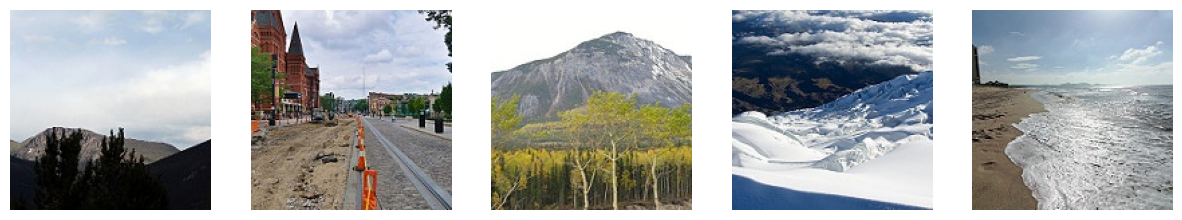

In [4]:
#Cell 3 — Load a sample of clean images

clean_images = glob.glob(os.path.join(clean_path, "**", "*.jpg"), recursive=True)
print("Total clean images found:", len(clean_images))

# take a random subset — 400 is plenty for this task
random.seed(42)
sample_paths = random.sample(clean_images, min(400, len(clean_images)))

# quick visual check
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, p in zip(axes, sample_paths[:5]):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
plt.show()

In [22]:
#Cell 4 — Feature extraction functions

def sharpness_score(gray):
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def brightness_stats(gray):
    mean_b = float(gray.mean())
    total = gray.size
    dark_frac = float(np.sum(gray < 15) / total)
    bright_frac = float(np.sum(gray > 240) / total)
    return mean_b, dark_frac, bright_frac

def contrast_score(gray):
    return float(gray.std())

def noise_score(gray):
    denoised = cv2.medianBlur(gray, 5)
    residual = gray.astype(np.float32) - denoised.astype(np.float32)
    return float(residual.std())

def saturation_stats(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    sat = hsv[:, :, 1].astype(np.float32)
    return float(sat.mean()), float(sat.std())

def edge_density(gray):
    edges = cv2.Canny(gray, 100, 200)
    return float(np.count_nonzero(edges) / edges.size)


def block_uniformity_score(gray, block_size=16):
    """
    Corruption heuristic v2: flags a block only if it's BOTH near-uniform
    internally AND abruptly different from its neighbors. Natural flat
    regions (sky, water) are uniform but transition smoothly to neighbors;
    corrupted/glitched blocks are uniform AND jump sharply against
    surrounding content (e.g. a black block dropped into a photo).
    """
    h, w = gray.shape
    if h < block_size * 3 or w < block_size * 3:
        return 0.0

    # precompute mean per block on a grid
    n_by, n_bx = h // block_size, w // block_size
    block_means = np.zeros((n_by, n_bx))
    block_stds = np.zeros((n_by, n_bx))
    for by in range(n_by):
        for bx in range(n_bx):
            block = gray[by*block_size:(by+1)*block_size, bx*block_size:(bx+1)*block_size]
            block_means[by, bx] = block.mean()
            block_stds[by, bx] = block.std()

    n_flagged, n_blocks = 0, 0
    for by in range(1, n_by - 1):
        for bx in range(1, n_bx - 1):
            n_blocks += 1
            if block_stds[by, bx] >= 1.0:
                continue  # not internally uniform, skip

            # compare to immediate neighbors' means
            neighbor_means = [
                block_means[by-1, bx], block_means[by+1, bx],
                block_means[by, bx-1], block_means[by, bx+1],
            ]
            max_diff = max(abs(block_means[by, bx] - nm) for nm in neighbor_means)

            # natural flat regions transition smoothly (~small diff);
            # corrupted blocks jump sharply against surroundings
            if max_diff > 25:
                n_flagged += 1

    return float(n_flagged / n_blocks) if n_blocks else 0.0


FEATURE_ORDER = ["sharpness", "mean_brightness", "dark_pixel_fraction",
                  "bright_pixel_fraction", "contrast", "noise",
                  "mean_saturation", "std_saturation", "edge_density", "block_uniformity"]

def extract_features(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    mean_b, dark_frac, bright_frac = brightness_stats(gray)
    mean_sat, std_sat = saturation_stats(bgr)
    return {
        "sharpness": sharpness_score(gray),
        "mean_brightness": mean_b,
        "dark_pixel_fraction": dark_frac,
        "bright_pixel_fraction": bright_frac,
        "contrast": contrast_score(gray),
        "noise": noise_score(gray),
        "mean_saturation": mean_sat,
        "std_saturation": std_sat,
        "edge_density": edge_density(gray),
        "block_uniformity": block_uniformity_score(gray),
    }

In [23]:
import inspect
print(inspect.getsource(block_uniformity_score))

def block_uniformity_score(gray, block_size=16):
    """
    Corruption heuristic v2: flags a block only if it's BOTH near-uniform
    internally AND abruptly different from its neighbors. Natural flat
    regions (sky, water) are uniform but transition smoothly to neighbors;
    corrupted/glitched blocks are uniform AND jump sharply against
    surrounding content (e.g. a black block dropped into a photo).
    """
    h, w = gray.shape
    if h < block_size * 3 or w < block_size * 3:
        return 0.0

    # precompute mean per block on a grid
    n_by, n_bx = h // block_size, w // block_size
    block_means = np.zeros((n_by, n_bx))
    block_stds = np.zeros((n_by, n_bx))
    for by in range(n_by):
        for bx in range(n_bx):
            block = gray[by*block_size:(by+1)*block_size, bx*block_size:(bx+1)*block_size]
            block_means[by, bx] = block.mean()
            block_stds[by, bx] = block.std()

    n_flagged, n_blocks = 0, 0
    for by in range(1, n_by - 1):
        fo

In [24]:
# test on the mountain lake image directly before full retrain
test_bgr = cv2.imread(sample_paths[0])  # replace with the lake image path if uploaded
old_score = block_uniformity_score(cv2.cvtColor(test_bgr, cv2.COLOR_BGR2GRAY))
print("New block_uniformity score:", old_score)
# should be near 0 now for a clean natural photo with sky

New block_uniformity score: 0.0


In [25]:
#Cell 6 — Synthetic degradation functions

def apply_blur(bgr, severity):
    k = {"low": 5, "medium": 11, "high": 21}[severity]
    return cv2.GaussianBlur(bgr, (k, k), 0)

def apply_underexposure(bgr, severity):
    factor = {"low": 0.6, "medium": 0.35, "high": 0.15}[severity]
    return np.clip(bgr.astype(np.float32) * factor, 0, 255).astype(np.uint8)

def apply_overexposure(bgr, severity):
    add = {"low": 60, "medium": 110, "high": 170}[severity]
    return np.clip(bgr.astype(np.float32) + add, 0, 255).astype(np.uint8)

def apply_noise(bgr, severity):
    sigma = {"low": 10, "medium": 25, "high": 45}[severity]
    noise = np.random.normal(0, sigma, bgr.shape).astype(np.float32)
    return np.clip(bgr.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def apply_corruption(bgr, severity):
    quality = {"low": 25, "medium": 10, "high": 3}[severity]
    ok, enc = cv2.imencode(".jpg", bgr, [cv2.IMWRITE_JPEG_QUALITY, quality])
    out = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    if severity in ("medium", "high"):
        h, w = out.shape[:2]
        n_blocks = {"medium": 2, "high": 6}[severity]
        block = max(8, min(h, w) // 8)
        for _ in range(n_blocks):
            y = random.randint(0, max(0, h - block))
            x = random.randint(0, max(0, w - block))
            out[y:y+block, x:x+block] = 0
    return out

DEGRADERS = {"blur": apply_blur, "underexposure": apply_underexposure,
             "overexposure": apply_overexposure, "noise": apply_noise,
             "corruption": apply_corruption}
ISSUE_TYPES = ["clean", "blur", "underexposure", "overexposure", "noise", "corruption"]

def make_labeled_sample(bgr, issue_type=None, severity=None):
    if issue_type is None:
        issue_type = random.choice(ISSUE_TYPES)
    if severity is None and issue_type != "clean":
        severity = random.choice(["low", "medium", "high"])

    if issue_type == "clean":
        out, severity = bgr.copy(), "none"
    else:
        out = DEGRADERS[issue_type](bgr, severity)

    if issue_type == "clean":
        score, label = random.randint(88, 100), "ACCEPTABLE"
    else:
        penalty = {"low": 20, "medium": 45, "high": 70}[severity]
        score = max(0, 95 - penalty + random.randint(-5, 5))
        label = "ACCEPTABLE" if score >= 70 else "DEGRADED" if score >= 40 else "DEFECTIVE"

    return out, issue_type, severity, label, score

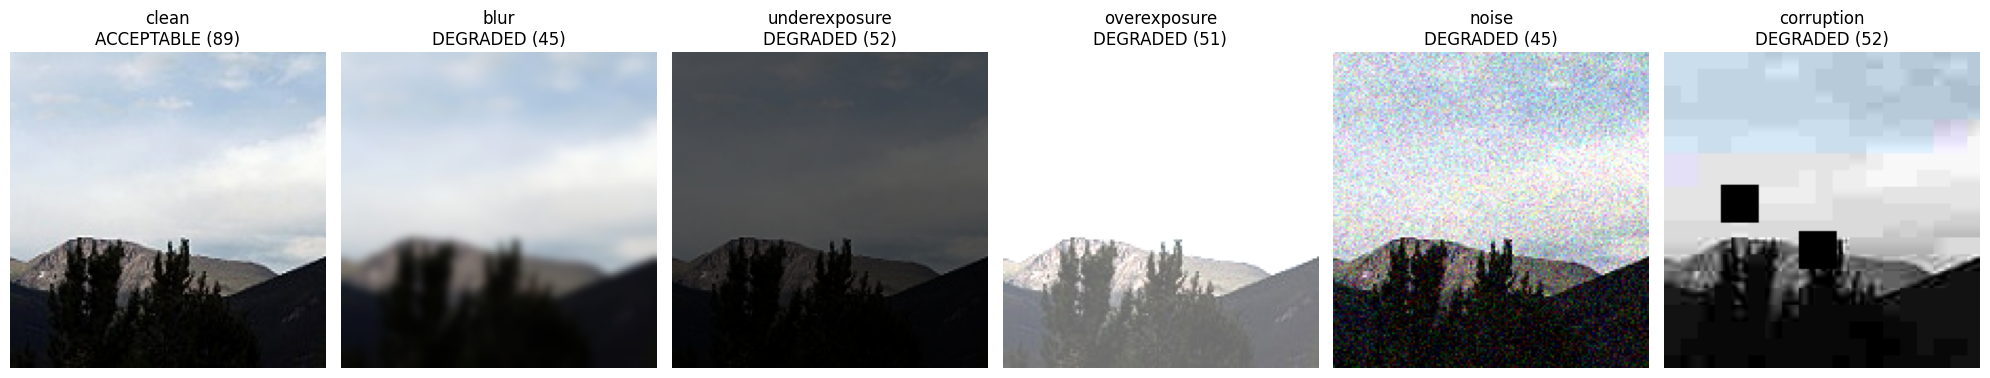

In [26]:
#Cell 7 — Visualize degradations (sanity check)

base = cv2.cvtColor(cv2.imread(sample_paths[0]), cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for ax, issue in zip(axes, ISSUE_TYPES):
    bgr = cv2.imread(sample_paths[0])
    degraded, itype, sev, label, score = make_labeled_sample(
        bgr, issue_type=issue, severity="medium" if issue != "clean" else None)
    rgb = cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    ax.set_title(f"{issue}\n{label} ({score})")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [27]:
#Cell 8 — Build the labeled dataset

def build_dataset(image_paths, n_per_image=6, max_dim=640):
    rows = []
    for i, p in enumerate(image_paths):
        bgr = cv2.imread(p)
        if bgr is None:
            continue
        h, w = bgr.shape[:2]
        if max(h, w) > max_dim:
            scale = max_dim / max(h, w)
            bgr = cv2.resize(bgr, (int(w*scale), int(h*scale)))

        for _ in range(n_per_image):
            degraded, issue_type, severity, label, score = make_labeled_sample(bgr)
            feats = extract_features(degraded)
            row = {"source_path": p, "issue_type": issue_type, "severity": severity,
                   "quality_label": label, "quality_score": score}
            row.update(feats)
            rows.append(row)

        if (i+1) % 50 == 0:
            print(f"processed {i+1}/{len(image_paths)} -> {len(rows)} samples")
    return pd.DataFrame(rows)

df = build_dataset(sample_paths, n_per_image=6)
df.to_csv("dataset.csv", index=False)
print(df.shape)
df.head()

processed 50/400 -> 300 samples
processed 100/400 -> 600 samples
processed 150/400 -> 900 samples
processed 200/400 -> 1200 samples
processed 250/400 -> 1500 samples
processed 300/400 -> 1800 samples
processed 350/400 -> 2100 samples
processed 400/400 -> 2400 samples
(2400, 15)


,source_path,issue_type,severity,quality_label,quality_score,sharpness,mean_brightness,dark_pixel_fraction,bright_pixel_fraction,contrast,noise,mean_saturation,std_saturation,edge_density,block_uniformity
0,/kaggle/input/intel-image-classification/seg_p...,blur,medium,DEGRADED,45,5.284308,148.616311,0.182978,0.036533,92.578737,1.076196,36.243732,34.785137,0.008578,0.0
1,/kaggle/input/intel-image-classification/seg_p...,underexposure,high,DEFECTIVE,23,27.007947,21.881422,0.329333,0.000000,14.138734,1.472005,38.014267,56.270584,0.000000,0.0
2,/kaggle/input/intel-image-classification/seg_p...,clean,none,ACCEPTABLE,100,1153.761832,148.592844,0.195778,0.040222,94.009666,9.568320,44.018845,55.632721,0.035333,0.0
3,/kaggle/input/intel-image-classification/seg_p...,noise,high,DEFECTIVE,27,12170.060120,148.340533,0.118267,0.094356,88.737739,25.459002,116.504448,86.183647,0.307556,0.0
4,/kaggle/input/intel-image-classification/seg_p...,clean,none,ACCEPTABLE,98,1153.761832,148.592844,0.195778,0.040222,94.009666,9.568320,44.018845,55.632721,0.035333,0.0


quality_label
ACCEPTABLE    1072
DEFECTIVE      687
DEGRADED       641
Name: count, dtype: int64

issue_type
blur             418
clean            408
underexposure    404
overexposure     403
corruption       394
noise            373
Name: count, dtype: int64


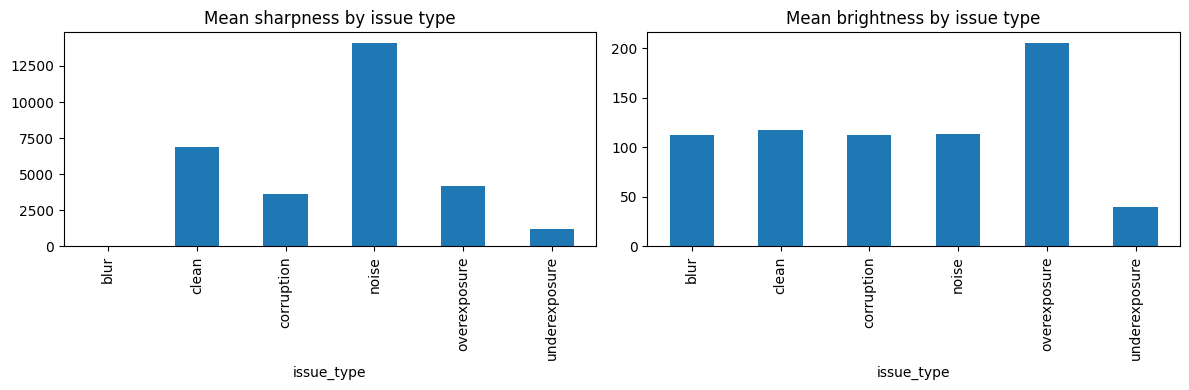

In [28]:
#Cell 9 — Explore the dataset

print(df["quality_label"].value_counts())
print()
print(df["issue_type"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby("issue_type")["sharpness"].mean().plot(kind="bar", ax=axes[0], title="Mean sharpness by issue type")
df.groupby("issue_type")["mean_brightness"].mean().plot(kind="bar", ax=axes[1], title="Mean brightness by issue type")
plt.tight_layout()
plt.show()

In [29]:
#Cell 10 — Train models

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, mean_absolute_error
import joblib

X = df[FEATURE_ORDER].values
y_label = df["quality_label"].values
y_score = df["quality_score"].values
y_issue = df["issue_type"].values

X_train, X_test, yl_train, yl_test, ys_train, ys_test, yi_train, yi_test = train_test_split(
    X, y_label, y_score, y_issue, test_size=0.2, random_state=42, stratify=y_label
)

# 1. Quality label classifier
clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, class_weight="balanced")
clf.fit(X_train, yl_train)
yl_pred = clf.predict(X_test)
print("=== Quality label ===")
print("Accuracy:", accuracy_score(yl_test, yl_pred))
print(classification_report(yl_test, yl_pred))

# 2. Quality score regressor
reg = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
reg.fit(X_train, ys_train)
ys_pred = reg.predict(X_test)
print("=== Quality score MAE ===", mean_absolute_error(ys_test, ys_pred))

# 3. Issue type classifier
issue_clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, class_weight="balanced")
issue_clf.fit(X_train, yi_train)
yi_pred = issue_clf.predict(X_test)
print("=== Issue type ===")
print("Accuracy:", accuracy_score(yi_test, yi_pred))
print(classification_report(yi_test, yi_pred))

=== Quality label ===
Accuracy: 0.8979166666666667
              precision    recall  f1-score   support

  ACCEPTABLE       0.87      0.96      0.91       215
   DEFECTIVE       0.94      0.99      0.96       137
    DEGRADED       0.90      0.70      0.79       128

    accuracy                           0.90       480
   macro avg       0.90      0.88      0.89       480
weighted avg       0.90      0.90      0.89       480

=== Quality score MAE === 7.649645153365352
=== Issue type ===
Accuracy: 0.8916666666666667
               precision    recall  f1-score   support

         blur       1.00      1.00      1.00        88
        clean       0.69      0.81      0.75        81
   corruption       0.90      0.74      0.81        76
        noise       0.83      0.77      0.80        70
 overexposure       0.99      1.00      0.99        82
underexposure       0.95      0.99      0.97        83

     accuracy                           0.89       480
    macro avg       0.89      0.89

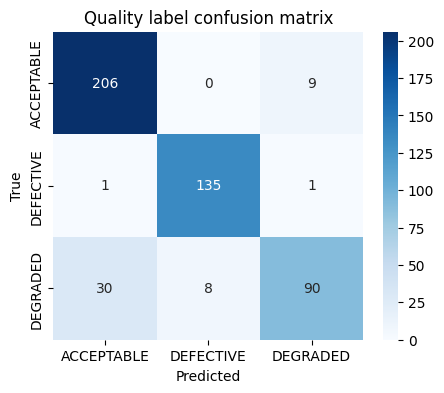

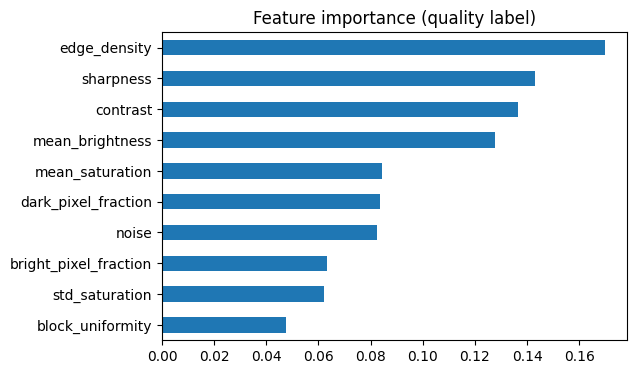

In [30]:
#Cell 11 — Confusion matrix + feature importance plots

import seaborn as sns

cm = confusion_matrix(yl_test, yl_pred, labels=clf.classes_)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clf.classes_, yticklabels=clf.classes_, cmap="Blues")
plt.title("Quality label confusion matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.show()

importances = pd.Series(clf.feature_importances_, index=FEATURE_ORDER).sort_values()
importances.plot(kind="barh", figsize=(6,4), title="Feature importance (quality label)")
plt.show()

In [ ]:
#Cell 12 — Save models for the backend

from pathlib import Path

backend_model_dir = Path("../models")
backend_model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(clf, backend_model_dir / "quality_label_clf.joblib")
joblib.dump(reg, backend_model_dir / "quality_score_reg.joblib")
joblib.dump(issue_clf, backend_model_dir / "issue_type_clf.joblib")
print(f"Saved backend models to {backend_model_dir.resolve()}.")

Saved.


In [32]:
#Cell 13 — Test on REAL blur dataset (generalization check)

blur_files = glob.glob(os.path.join(blur_path, "**", "*.jpg"), recursive=True)
print("Blur dataset files found:", len(blur_files))
# inspect folder structure first if this is 0 — dataset layout can vary
for root, dirs, files in os.walk(blur_path):
    print(root, len(files))

Blur dataset files found: 1476
/kaggle/input/blur-dataset 0
/kaggle/input/blur-dataset/defocused_blurred 350
/kaggle/input/blur-dataset/sharp 350
/kaggle/input/blur-dataset/motion_blurred 350
/kaggle/input/blur-dataset/blur_dataset_scaled 0
/kaggle/input/blur-dataset/blur_dataset_scaled/defocused_blurred 350
/kaggle/input/blur-dataset/blur_dataset_scaled/sharp 350
/kaggle/input/blur-dataset/blur_dataset_scaled/motion_blurred 350


In [33]:
#Cell 14 — Predict on real images + inspect

def predict_on_image(path):
    bgr = cv2.imread(path)
    if bgr is None:
        return None
    feats = extract_features(bgr)
    x = np.array([feats[k] for k in FEATURE_ORDER]).reshape(1, -1)
    label = clf.predict(x)[0]
    score = float(reg.predict(x)[0])
    issue = issue_clf.predict(x)[0]
    return label, round(score,1), issue, feats

sample_real = random.sample(blur_files, min(10, len(blur_files)))
for p in sample_real:
    result = predict_on_image(p)
    print(os.path.basename(p), "->", result[:3])

213_ONEPLUS-3T_S.jpg -> ('ACCEPTABLE', 78.5, 'corruption')
63_HUAWEI-P20_F.jpg -> ('DEGRADED', 38.3, 'blur')
313_XIAOMI-PROCOFONE-F1_F.jpg -> ('DEFECTIVE', 26.7, 'blur')
215_LG-Q6_M.jpg -> ('DEFECTIVE', 27.7, 'blur')
161_XIAOMI-MI8-SE_F.jpg -> ('DEFECTIVE', 24.4, 'blur')
128_XIAOMI-MI8-SE_M.jpg -> ('ACCEPTABLE', 71.3, 'clean')
26_HONOR-8X_M.jpg -> ('DEFECTIVE', 30.3, 'blur')
99_HONOR-7X_F.jpg -> ('DEGRADED', 37.5, 'blur')
36_HONOR-8X_F.jpg -> ('DEGRADED', 32.9, 'blur')
213_ONEPLUS-3T_M.jpg -> ('DEFECTIVE', 28.6, 'blur')


In [37]:
import gradio as gr
import cv2
import numpy as np
import os

def gradio_analyze(image):
    if image is None:
        return "Please upload an image.", None

    bgr = cv2.imread(image)
    if bgr is None:
        return "❌ Could not read image.", None

    feats = extract_features(bgr)
    x = np.array([feats[k] for k in FEATURE_ORDER]).reshape(1, -1)

    label = clf.predict(x)[0]
    label_proba = dict(zip(clf.classes_, clf.predict_proba(x)[0].tolist()))
    score = float(np.clip(reg.predict(x)[0], 0, 100))

    issue_pred = issue_clf.predict(x)[0]
    issue_proba = dict(zip(issue_clf.classes_, issue_clf.predict_proba(x)[0].tolist()))

    label_confidence_val = max(label_proba.values())

    issues_list = []
    # Only report issues if the quality label itself signals a problem,
    # OR if the issue-type confidence is genuinely strong (not borderline).
    if label != "ACCEPTABLE" or issue_proba.get(issue_pred, 0.0) > 0.45:
        if issue_pred != "clean":
            conf = issue_proba.get(issue_pred, 0.0)
            severity = "high" if conf > 0.75 else "medium" if conf > 0.5 else "low"
            issues_list.append({"type": issue_pred, "severity": severity, "confidence": round(conf, 3)})

        for itype, prob in sorted(issue_proba.items(), key=lambda kv: -kv[1]):
            if itype in ("clean", issue_pred):
                continue
            if prob > 0.35:  # raised threshold from 0.25 to reduce noisy secondary flags
                issues_list.append({"type": itype, "severity": "low", "confidence": round(prob, 3)})

    summary = f"### Quality: **{label}**  (score: {round(score,1)}/100)\n\n"
    summary += f"**Confidence:** {round(label_confidence_val,3)}\n\n"
    summary += "**Detected issues:**\n"
    if issues_list:
        for iss in issues_list:
            summary += f"- `{iss['type']}` — severity: {iss['severity']}, confidence: {iss['confidence']}\n"
    else:
        summary += "- None detected ✅\n"

    summary += "\n**Image statistics:**\n"
    for k, v in feats.items():
        if k in FEATURE_ORDER:
            summary += f"- {k}: {round(v,4)}\n"

    result_json = {
        "quality_score": round(score, 1),
        "quality_label": label,
        "issues": issues_list,
        "confidence": round(label_confidence_val, 3),
        "label_probabilities": {k: round(v,3) for k,v in label_proba.items()},
    }

    return summary, result_json

with gr.Blocks(title="Image Quality Detector — Notebook Test") as demo:
    gr.Markdown("# AI Image Quality & Defect Detection (notebook test)")
    gr.Markdown("Upload an image to test the trained model before porting to backend.")

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="filepath", label="Upload Image")
            analyze_btn = gr.Button("Analyze", variant="primary")
        with gr.Column():
            result_md = gr.Markdown()
            result_json = gr.JSON(label="Raw JSON")

    analyze_btn.click(fn=gradio_analyze, inputs=[image_input], outputs=[result_md, result_json])

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://19d2b465aef41ea2a5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://19d2b465aef41ea2a5.gradio.live


In [ ]:
# Backend integration — verify artifacts and call the running API
from pathlib import Path
import json
import requests
import joblib

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "backend").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_FILES = {
    "quality_label_clf": MODEL_DIR / "quality_label_clf.joblib",
    "quality_score_reg": MODEL_DIR / "quality_score_reg.joblib",
    "issue_type_clf": MODEL_DIR / "issue_type_clf.joblib",
}

for name, path in MODEL_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing backend model: {path}")
    model = joblib.load(path)
    print(f"{name}: {path.name} ({path.stat().st_size:,} bytes)")
    if hasattr(model, "feature_names_in_"):
        print("  features:", list(model.feature_names_in_))
    else:
        print("  features:", getattr(model, "n_features_in_", "unknown"))

API_URL = "http://127.0.0.1:7860"
health = requests.get(f"{API_URL}/health", timeout=10)
health.raise_for_status()
print("Backend health:", health.json())

image_path = Path(sample_paths[0])
with image_path.open("rb") as image_file:
    response = requests.post(
        f"{API_URL}/analyze",
        files={"file": (image_path.name, image_file, "image/jpeg")},
        timeout=60,
    )
response.raise_for_status()
backend_result = response.json()
print(json.dumps(backend_result, indent=2))